# PHASE 1 — DATA UNDERSTANDING & EDA

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [32]:
fake=pd.read_csv('Fake.csv')
true=pd.read_csv('True.csv')


In [33]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [34]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [35]:
#Adding a new column 'class' to both fake and true datasets. 
# The 'class' column will have a value of 0 for fake news and 1 for true news.
fake['class']=0
true['class']=1

In [36]:
# concatenating the fake and true datasets to create a single dataset for analysis.
data=pd.concat([fake,true],axis=0)

In [37]:
data.sample(10)

,title,text,subject,date,class
17488,Pakistan official details car chase that freed...,(This version of the story corrects spelling ...,worldnews,"October 13, 2017",1
14191,Arrested Indonesian parliament speaker pleads ...,JAKARTA (Reuters) - Indonesia s speaker of par...,worldnews,"November 22, 2017",1
19508,New Zealand calls in navy to beat jet fuel sho...,WELLINGTON (Reuters) - A New Zealand navy vess...,worldnews,"September 21, 2017",1
3541,Trump’s Lapdog Chris Christie Breaks ALL TIME...,Remember when Chris Christie was a contender f...,News,"December 6, 2016",0
14024,DEMOCRATS FREAK OUT As Shocking Number Of Unio...,As millions of dollars of union dues flow into...,politics,"Apr 27, 2016",0
3437,Paris climate deal cannot be renegotiated: EU ...,BRUSSELS (Reuters) - The Paris climate agreeme...,politicsNews,"June 2, 2017",1
2981,"Trump STRANDED, In Full Panic As ANOTHER Perf...",President-elect Donald Trump has had trouble f...,News,"January 16, 2017",0
12191,HYSTERICAL! DELUSIONAL HILLARY CLAIMS “EPIDEMI...,Hillary Clinton on Thursday decried the spread...,politics,"Dec 8, 2016",0
12945,YIKES! Tomi Lahren DEMOLISHES Hillary: “How Da...,Wow! Bravo Tomi! You really nailed it this tim...,politics,"Sep 22, 2016",0
20991,"UK police arrest four, including soldiers, ove...",LONDON (Reuters) - British police arrested fou...,worldnews,"September 5, 2017",1


In [38]:
# dropping the 'title', 'subject', and 'date' columns from the dataset as 
# they may not be relevant for the analysis.
# because we are interested in analyzing the content of the news articles to determine if they are fake or true,
#  and these columns may not provide useful information for that purpose.
data.drop(['title','subject','date'],axis=1,inplace=True)

In [39]:
data.sample(10)

,text,class
7321,"JANESVILLE, Wisc. (Reuters) - Semi-retired Wis...",1
8563,It s hard to believe that it s been nearly 13 ...,0
18039,HAVANA (Reuters) - The man forecast to replace...,1
7625,"In a shocking moment of confession, Morning Jo...",0
2076,Trump spent the weekend golfing in Florida. By...,0
21695,Why should Barack Obama bother with the courts...,0
4151,WASHINGTON (Reuters) - Bank of Japan Governor ...,1
6093,"An elderly, disabled couple in New Hampshire i...",0
5022,Donald Trump thought he could distract America...,0
21133,NAIROBI (Reuters) - Kenyan President Uhuru Ken...,1


In [41]:
data.reset_index(inplace=True)
#why because after concatenating the two datasets,
#the index of the resulting dataset may not be sequential and may contain duplicate values.
# By resetting the index, we can create a new sequential index for the combined dataset, which
# ensures that each row in the dataset has a unique and sequential index value.

In [42]:
data.drop(['index'],axis=1,inplace=True)
# why because after resetting the index,
#  a new column named 'index' is created in the dataset, which contains the old index values.
# Since we no longer need the old index values, 
# we can drop the 'index' column from the dataset to clean up the data and avoid confusion.

In [44]:
data.sample(5)

,text,class
30421,BEIJING (Reuters) - U.S. President-elect Donal...,1
9907,You have to love this! A Florida man greeted P...,0
23933,LONDON (Reuters) - Britain’s ambassador to the...,1
39760,OSLO (Reuters) - Hopes of finding survivors fr...,1
33436,WASHINGTON (Reuters) - The U.S. Congress was i...,1


In [45]:
data.isnull().sum()

text     0
class    0
dtype: int64

In [46]:
data.value_counts('class')

class
0    23481
1    21417
Name: count, dtype: int64

In [48]:
# dupilicate values
data.duplicated().sum()
data.drop_duplicates(inplace=True)

In [49]:
data.value_counts('class')

class
1    21192
0    17455
Name: count, dtype: int64

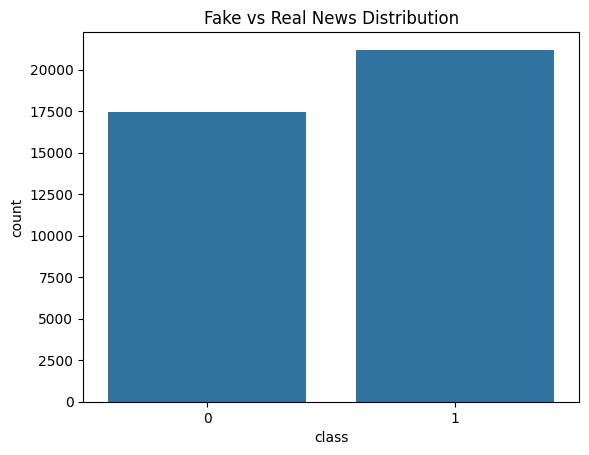

In [53]:
#
import seaborn as sns

sns.countplot(x="class", data=data)
plt.title("Fake vs Real News Distribution")
plt.show()

In [54]:
## What is text preprocessing?
## Text preprocessing is the process of cleaning and transforming 
# raw text data into a format that can be easily analyzed and used for various natural language processing (NLP) tasks.

# | Problem                             | Cleaning Fix           |
# | ----------------------------------- | ---------------------- |
# | Uppercase/lowercase mismatch        | Convert to lowercase   |
# | Punctuation noise                   | Remove punctuation     |
# | Stopwords ("the", "is", "and")      | Remove stopwords       |
# | Emojis & special symbols            | Remove them            |
# | Extra spaces                        | Remove                 |
# | Word variations ("running", "runs") | Stemming/Lemmatization |


In [56]:
import re

def clean_text(text):
    
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove text inside square brackets
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)
    
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove new line characters
    text = re.sub(r'\n', ' ', text)
    
    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [57]:
data['text'] = data['text'].apply(clean_text)

In [58]:
data.sample(5)

,text,class
15727,this is the definition of insanitydoing the sa...,0
8989,after going to all the trouble of leaving thei...,0
24374,paterson nj reuters with its enormous muslim p...,1
11602,wow john mccain is leading a vicious campaign ...,0
29114,corrects first paragraph to make it jurist ins...,1


In [61]:
# convert dataset into csv file
data.to_csv('cleaned_fake_news.csv', index=False)